In [25]:
import pandas as pd 
data = pd.read_csv("cars_detailed.csv")
print(data.columns)
print(data.dtypes)
data.count()

Index(['Brand', 'Model', 'Version Name', 'Price', 'Price Numeric (DT)',
       'Original Price', 'Original Price Numeric (DT)', 'Is Promo', 'Status',
       'URL',
       ...
       'Porte bagages', 'Capote éléctrique', 'Stores pare-soleil',
       'Sideblades', 'Launch Control', 'Rideau de benne', 'Jupes latérales',
       'Portes en élytre', 'Contrôle adaptatif de la charge',
       'Dynamic Response'],
      dtype='object', length=174)
Brand                              object
Model                              object
Version Name                       object
Price                              object
Price Numeric (DT)                  int64
                                    ...  
Rideau de benne                    object
Jupes latérales                    object
Portes en élytre                   object
Contrôle adaptatif de la charge    object
Dynamic Response                   object
Length: 174, dtype: object


Brand                              551
Model                              551
Version Name                       551
Price                              551
Price Numeric (DT)                 551
                                  ... 
Rideau de benne                    551
Jupes latérales                    551
Portes en élytre                   551
Contrôle adaptatif de la charge    551
Dynamic Response                   551
Length: 174, dtype: int64

In [26]:
brand = data['Brand'].unique()
print(brand)


['Skoda' 'Suzuki' 'Avantier' 'Renault' 'Chery' 'Hyundai' 'KIA' 'Cenntro'
 'DFSK' 'Citroën' 'Changan' 'Tata' 'Mahindra' 'Dongfeng' 'BYD' 'Geely'
 'Dacia' 'Nissan' 'Opel' 'MG' 'Peugeot' 'Seat' 'Fiat' 'Volkswagen' 'JMC'
 'Honda' 'Deepal' 'GWM' 'Omoda' 'Toyota' 'Ssangyong' 'Wallyscar' 'Faw'
 'GAC' 'Lynk' 'Jetour' 'Volvo' 'Mini' 'Xpeng' 'Ford' 'Jeep' 'Cupra' 'IM'
 'BMW' 'Audi' 'Mercedes-Benz' 'Discovery' 'Porsche' 'Jaguar' 'Range'
 'Defender' 'JAC' 'Bako' 'Mitsubishi' 'JMEV' 'Foton' 'Chevrolet' 'Foday']


In [27]:
# Count occurrences of each brand
brand_count = {}

for key in brand:  # brand is the array of unique values
    val = data['Brand'].tolist().count(key)  # count how many times each brand appears
    brand_count[key] = {
        "title": key,
        "counts": val
    }

print(brand_count)


{'Skoda': {'title': 'Skoda', 'counts': 16}, 'Suzuki': {'title': 'Suzuki', 'counts': 13}, 'Avantier': {'title': 'Avantier', 'counts': 2}, 'Renault': {'title': 'Renault', 'counts': 11}, 'Chery': {'title': 'Chery', 'counts': 8}, 'Hyundai': {'title': 'Hyundai', 'counts': 28}, 'KIA': {'title': 'KIA', 'counts': 23}, 'Cenntro': {'title': 'Cenntro', 'counts': 4}, 'DFSK': {'title': 'DFSK', 'counts': 16}, 'Citroën': {'title': 'Citroën', 'counts': 11}, 'Changan': {'title': 'Changan', 'counts': 3}, 'Tata': {'title': 'Tata', 'counts': 4}, 'Mahindra': {'title': 'Mahindra', 'counts': 10}, 'Dongfeng': {'title': 'Dongfeng', 'counts': 8}, 'BYD': {'title': 'BYD', 'counts': 7}, 'Geely': {'title': 'Geely', 'counts': 15}, 'Dacia': {'title': 'Dacia', 'counts': 5}, 'Nissan': {'title': 'Nissan', 'counts': 5}, 'Opel': {'title': 'Opel', 'counts': 8}, 'MG': {'title': 'MG', 'counts': 17}, 'Peugeot': {'title': 'Peugeot', 'counts': 18}, 'Seat': {'title': 'Seat', 'counts': 13}, 'Fiat': {'title': 'Fiat', 'counts': 10}

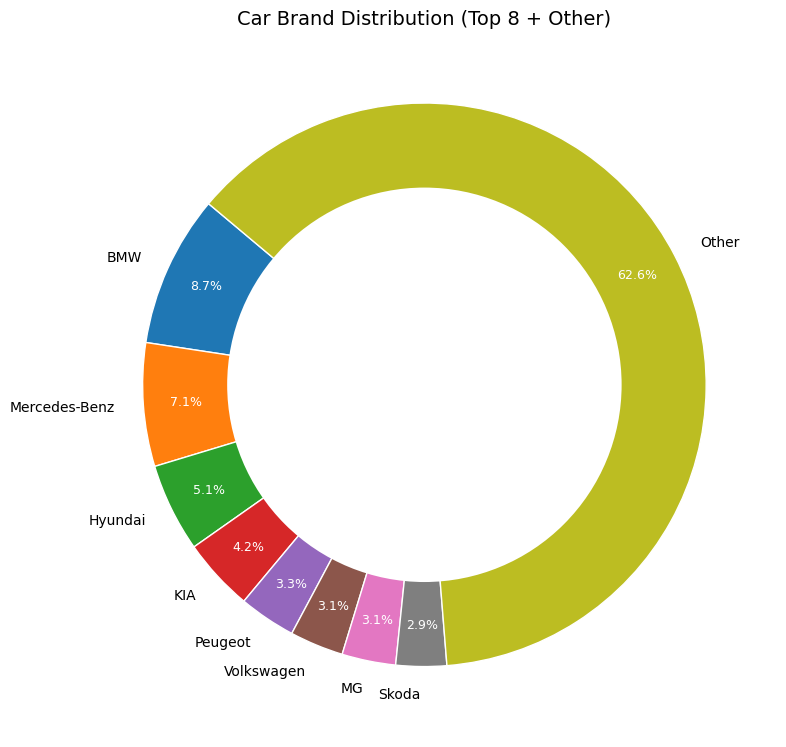

In [33]:
import matplotlib.pyplot as plt

# Step 1: Count brands
brand_counts = data['Brand'].value_counts()

# Step 2: Keep top N brands, group the rest
top_n = 8   # show only top 8 brands
main_brands = brand_counts[:top_n]
other_count = brand_counts[top_n:].sum()

if other_count > 0:
    main_brands["Other"] = other_count

# Step 3: Plot donut chart
plt.figure(figsize=(8,8))
wedges, texts, autotexts = plt.pie(
    main_brands.values,
    labels=main_brands.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    wedgeprops={'edgecolor':'white'}
)

# Style labels
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
    autotext.set_color("white")

# Donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Car Brand Distribution (Top 8 + Other)", fontsize=14)
plt.tight_layout()
plt.show()


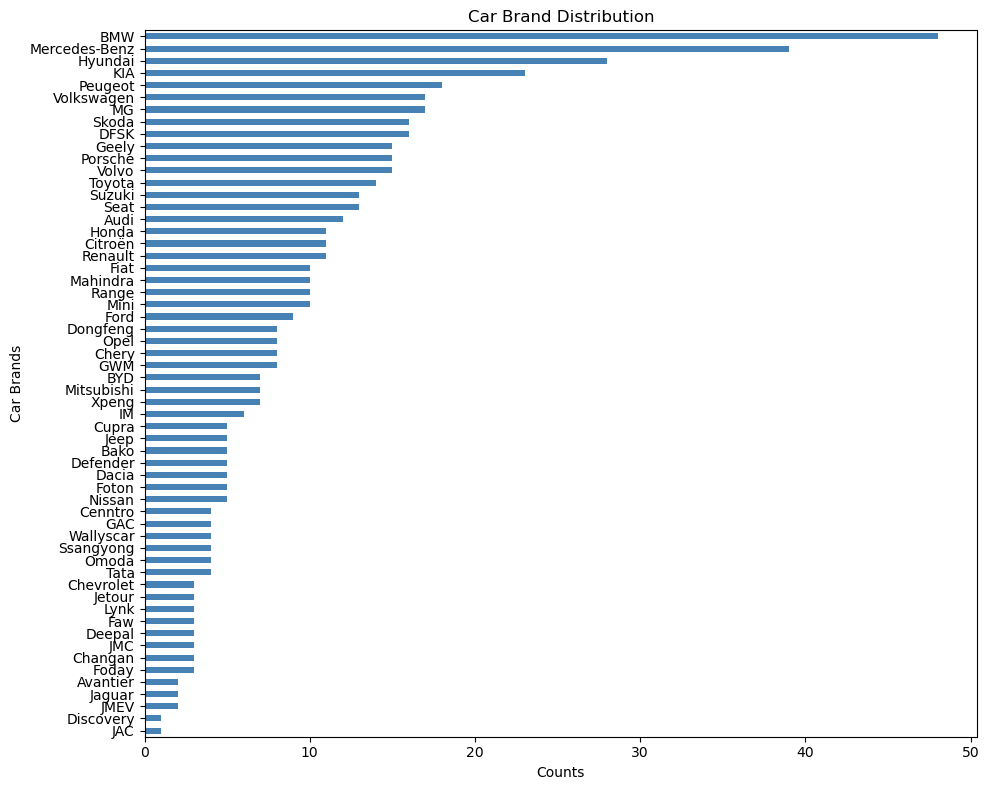

In [34]:
import matplotlib.pyplot as plt

# Step 1: Count brands
brand_counts = data['Brand'].value_counts()

# Step 2: Plot horizontal bar chart
plt.figure(figsize=(10,8))
brand_counts.plot(kind="barh", color="steelblue")

plt.xlabel("Counts")
plt.ylabel("Car Brands")
plt.title("Car Brand Distribution")
plt.gca().invert_yaxis()  # largest brands at the top
plt.tight_layout()
plt.show()
